In [1]:
#0. 작업 준비
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils import data
from torchvision import datasets,transforms, utils
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
USE_CUDA=torch.cuda.is_available()
DEVICE=torch.device('cuda' if USE_CUDA else 'cpu')

In [2]:
tr_ds=datasets.MNIST(root='./data/',
                     train=True,
                     download=True,
                     transform=transforms.Compose([transforms.ToTensor()]))

In [3]:
BATCH_SIZE=60000
tr_ds_loader=torch.utils.data.DataLoader(
    dataset=tr_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)
img,_=next(iter(tr_ds_loader))
img.shape
img.mean(),img.std()

(tensor(0.1307), tensor(0.3081))

In [4]:
BATCH_SIZE=64
EPOCHS=10

In [5]:
# 데이터 수정 (노이즈 삽입)
# 1. 데이터 준비
transform=transforms.Compose([
    #transforms.RandomHorizontalFlip(),#데이터 증강(노이즈삽입)
    transforms.ToTensor(),#입력 데이터 정리
    #transforms.Normalize((0.1307,),(0.3081,))
])#데이터 사용 방식 내용 결정
tr_ds_loader=torch.utils.data.DataLoader(
    datasets.MNIST('./data/',
        train=True,
        download=False,
        transform=transform
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)
tt_ds_loader=torch.utils.data.DataLoader(
    datasets.MNIST('./data/',
        train=False,
        transform=transform
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [6]:
class 모델(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder=nn.Sequential(
            nn.Linear(28*28,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,12),
            nn.ReLU(),
            nn.Linear(12,3)
            )
        self.decoder=nn.Sequential(
            nn.Linear(3,12),
            nn.ReLU(),
            nn.Linear(12,64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,28*28),
            nn.Sigmoid()
            )
    def forward(self,x):
        encoded=self.encoder(x)
        decoded=self.decoder(encoded)
        return encoded,decoded

In [7]:
autoencoder=모델().to(DEVICE)
opt=optim.Adam(autoencoder.parameters(),lr=0.005)
criterion=nn.MSELoss()

In [8]:
v_img=tr_ds.data[:5].view(-1,28*28)
v_img=v_img.type(torch.FloatTensor)/255.
v_img.shape

torch.Size([5, 784])

In [9]:
def train(m,tr_ds_loader):
    m.train()
    for i,(x,y) in enumerate(tr_ds_loader):
        data=x.view(-1,28*28).to(DEVICE)
        target=x.view(-1,28*28).to(DEVICE)
        label=y.to(DEVICE)

        encoded,decoded=m(data)

        loss=criterion(decoded,target)
        opt.zero_grad()
        loss.backward()
        opt.step()

1회


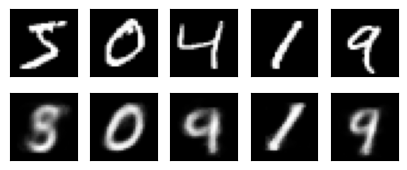

2회


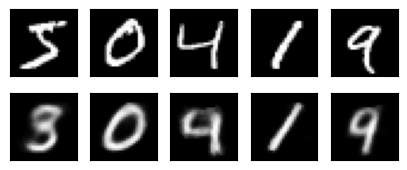

3회


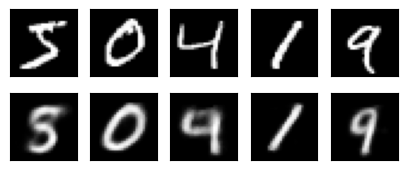

4회


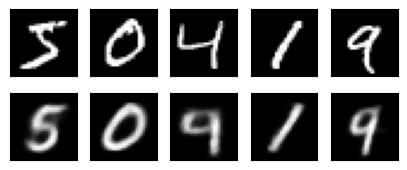

5회


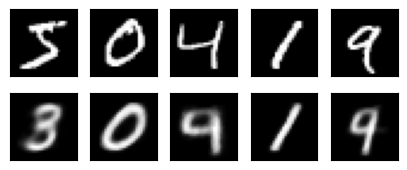

6회


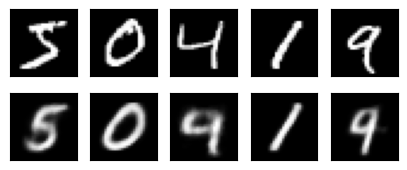

7회


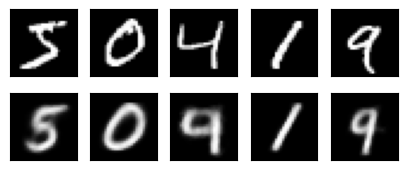

8회


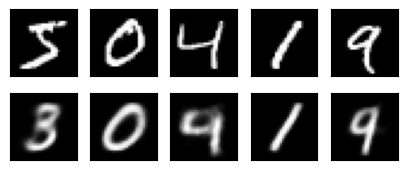

9회


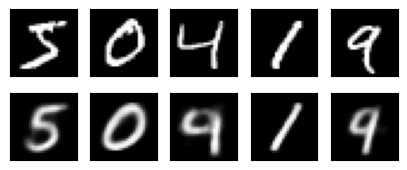

10회


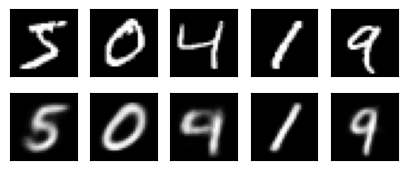

In [10]:
for epoch in range(1,EPOCHS+1):
    train(autoencoder,tr_ds_loader)

    tt_x=v_img.to(DEVICE)
    _,dc_data=autoencoder(tt_x)

    fig,a=plt.subplots(2,5,figsize=(5,2))
    print(f'{epoch}회')
    for i in range(5):
        img=v_img.data.numpy()[i].reshape(28,28)
        a[0][i].imshow(img,cmap='gray')
        a[0][i].set_xticks(())
        a[0][i].set_yticks(())
    for i in range(5):
        img=dc_data.to('cpu').data.numpy()[i].reshape(28,28)
        a[1][i].imshow(img,cmap='gray')
        a[1][i].set_xticks(())
        a[1][i].set_yticks(())
    plt.show()
    

# 패션 MNIST 데이터를 이용하여 오토인코더를 설계하고 학습하시오

1회


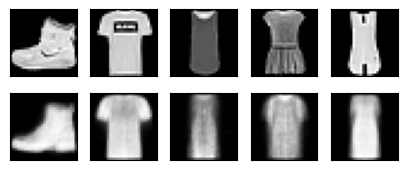

2회


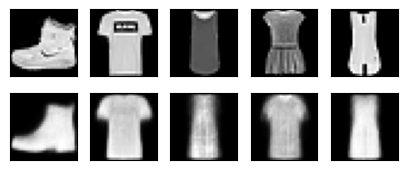

3회


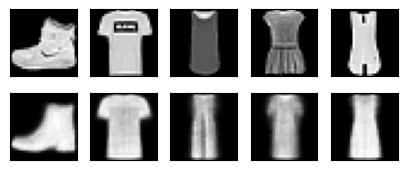

4회


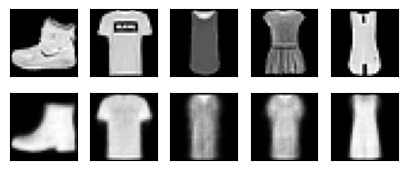

5회


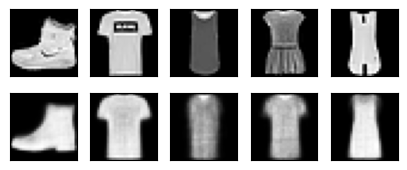

6회


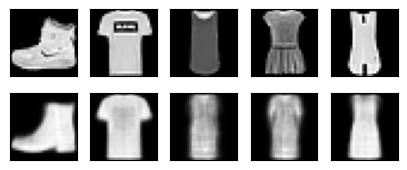

7회


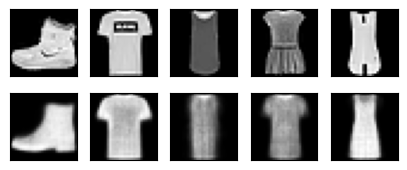

8회


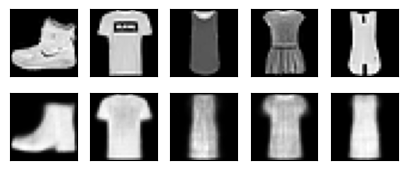

9회


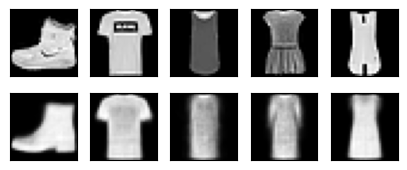

10회


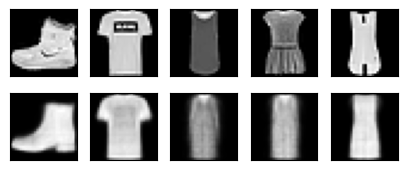

In [12]:
BATCH_SIZE=64
EPOCHS=10
transform=transforms.Compose([
    transforms.ToTensor(),
])
tr_ds=datasets.FashionMNIST(root='./data/',
                     train=True,
                     download=True,
                     transform=transform)
tr_ds_loader=torch.utils.data.DataLoader(
    tr_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)
tt_ds_loader=torch.utils.data.DataLoader(
    tr_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)
class 모델(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder=nn.Sequential(
            nn.Linear(28*28,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,12),
            nn.ReLU(),
            nn.Linear(12,3)
            )
        self.decoder=nn.Sequential(
            nn.Linear(3,12),
            nn.ReLU(),
            nn.Linear(12,64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,28*28),
            nn.Sigmoid()
            )
    def forward(self,x):
        encoded=self.encoder(x)
        decoded=self.decoder(encoded)
        return encoded,decoded
autoencoder=모델().to(DEVICE)
opt=optim.Adam(autoencoder.parameters(),lr=0.005)
criterion=nn.MSELoss()
v_img=tr_ds.data[:5].view(-1,28*28)
v_img=v_img.type(torch.FloatTensor)/255.
def train(m,tr_ds_loader):
    m.train()
    for i,(x,y) in enumerate(tr_ds_loader):
        data=x.view(-1,28*28).to(DEVICE)
        target=x.view(-1,28*28).to(DEVICE)
        label=y.to(DEVICE)

        encoded,decoded=m(data)

        loss=criterion(decoded,target)
        opt.zero_grad()
        loss.backward()
        opt.step()
for epoch in range(1,EPOCHS+1):
    train(autoencoder,tr_ds_loader)

    tt_x=v_img.to(DEVICE)
    _,dc_data=autoencoder(tt_x)

    fig,a=plt.subplots(2,5,figsize=(5,2))
    print(f'{epoch}회')
    for i in range(5):
        img=v_img.data.numpy()[i].reshape(28,28)
        a[0][i].imshow(img,cmap='gray')
        a[0][i].set_xticks(())
        a[0][i].set_yticks(())
    for i in range(5):
        img=dc_data.to('cpu').data.numpy()[i].reshape(28,28)
        a[1][i].imshow(img,cmap='gray')
        a[1][i].set_xticks(())
        a[1][i].set_yticks(())
    plt.show()
    

In [13]:
tr_ds=datasets.FashionMNIST(root='./data/',train=True,download=False,transform=transforms.ToTensor())
tr_ds_loader=torch.utils.data.DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True)

In [14]:
autoencoder=모델().to(DEVICE)
opt=optim.Adam(autoencoder.parameters(),lr=0.005)
criterion=nn.MSELoss()

In [15]:
def add_noise(img):
    noise=torch.randn(img.size())*0.2
    noise_img=img+noise
    return noise_img

In [16]:
def train(m,tr_ds_loader):
    m.train()
    avg_loss=0
    for i,(x,y) in enumerate(tr_ds_loader):
        noise_img=add_noise(x)
        data=noise_img.view(-1,28*28).to(DEVICE)
        target=x.view(-1,28*28).to(DEVICE)
        label=y.to(DEVICE)

        encoded,decoded=m(data)

        loss=criterion(decoded,target)
        opt.zero_grad()
        loss.backward()
        opt.step()

        avg_loss+=loss.item()
    return avg_loss/len(tr_ds_loader)

In [17]:
for epoch in range(1,EPOCHS+1):
    loss=train(autoencoder,tr_ds_loader)
    print(f'{epoch}회 loss:{loss}')

1회 loss:0.041061961086097554
2회 loss:0.028765342051365862
3회 loss:0.02601534308099162
4회 loss:0.024975703475174745
5회 loss:0.02441770165785353
6회 loss:0.02388041048471544
7회 loss:0.023582391905536782
8회 loss:0.02339912929347774
9회 loss:0.023186975385127928
10회 loss:0.022991276093955234


In [18]:
tt_ds=datasets.FashionMNIST(root='./data/',train=False,download=False,transform=transforms.ToTensor())
tt_ds_loader=torch.utils.data.DataLoader(tt_ds,batch_size=BATCH_SIZE,shuffle=True)
sample_data=tt_ds.data[0].view(-1,28*28)
sample_data=sample_data.type(torch.FloatTensor)/255
oj_data=sample_data[0]
noist_data=add_noise(oj_data).to(DEVICE)
_,output=autoencoder(noist_data)

In [19]:
output.size(),oj_data.size(),noist_data.size()

(torch.Size([784]), torch.Size([784]), torch.Size([784]))

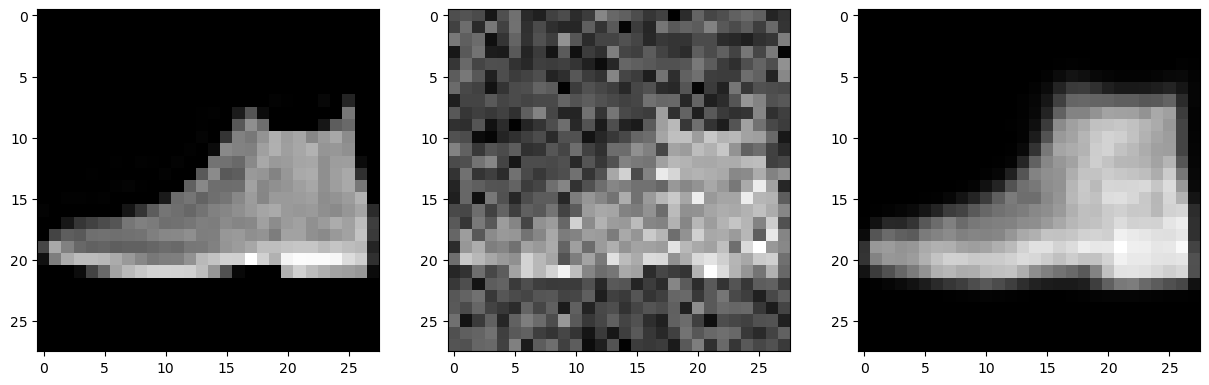

In [20]:
fig,a=plt.subplots(1,3,figsize=(15,15))
oj_img=oj_data.to('cpu').data.numpy().reshape(28,28)
noisy_img=noist_data.to('cpu').data.numpy().reshape(28,28)
out_img=output.to('cpu').data.numpy().reshape(28,28)
oj_img.shape,noisy_img.shape,out_img.shape
a[0].imshow(oj_img,cmap='gray')
a[1].imshow(noisy_img,cmap='gray')
a[2].imshow(out_img,cmap='gray')

In [21]:
BATCH_SIZE=64
tr_ds=datasets.FashionMNIST(root='./data/',train=True,download=True,transform=transforms.ToTensor())
tr_ds_loader=torch.utils.data.DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True)

In [22]:
G=nn.Sequential(
    nn.Linear(64,256),
    nn.ReLU(),
    nn.Linear(256,256),
    nn.ReLU(),
    nn.Linear(256,784),
    nn.Tanh()
)

In [23]:
D=nn.Sequential(
    nn.Linear(784,256),
    nn.LeakyReLU(0.2),
    nn.Linear(256,256),
    nn.LeakyReLU(0.2),
    nn.Linear(256,1),
    nn.Sigmoid()
)

In [24]:
G=G.to(DEVICE)
D=D.to(DEVICE)

In [25]:
criterion=nn.BCELoss()
d_opt=optim.Adam(D.parameters(),lr=0.0002)
G_opt=optim.Adam(G.parameters(),lr=0.0002)

In [26]:
BATCH_SIZE

64

In [27]:
for i,(x,_) in enumerate(tr_ds_loader):
    print(x.shape)
    data=x.reshape(BATCH_SIZE,-1)
    print(data.shape)
    output=D(data)
    break

torch.Size([64, 1, 28, 28])
torch.Size([64, 784])


In [28]:
EPOCHS=10
for epoch in range(1,EPOCHS+1):
    for i,(x,_) in enumerate(tr_ds_loader):
        #data=x.reshape(-1,784).to(DEVICE)
        
        data=x.reshape(BATCH_SIZE,-1).to(DEVICE)
        #print(data.shape[-1])
        if data.shape[-1]!=784:
            continue
        r_label=torch.ones(BATCH_SIZE,1).to(DEVICE)
        f_label=torch.zeros(BATCH_SIZE,1).to(DEVICE)
        #1. 진짜 데이터 판별
        #print(data.shape)
        output=D(data)
        d_loss_real=criterion(output,r_label)
        real_sc=output

        z=torch.randn(BATCH_SIZE,64).to(DEVICE)
        f_data=G(z)

        #2. 가짜 데이터 판별
        output=D(f_data)
        d_loss_fake=criterion(output,f_label)
        fake_sc=output
        #판별오차 토출
        d_loss=d_loss_real+d_loss_fake

        #초기화
        G_opt.zero_grad()
        d_opt.zero_grad()
        #판별자 학습
        d_loss.backward()
        d_opt.step()

        #생성오차 도출
        f_data=G(z)
        output=D(f_data)
        g_loss=criterion(output,r_label)
        

        #생성자 학습
        G_opt.zero_grad()
        d_opt.zero_grad()
        g_loss.backward()
        G_opt.step()
        
    print(f"{epoch}회 d_loss{d_loss.item()},g_loss{g_loss.item()}, D(G(z)):{fake_sc.mean()},D(x):{real_sc.mean()}")

0회 d_loss0.795998752117157,g_loss1.9223897457122803, D(G(z)):0.2804238200187683,D(x):0.7369500994682312
1회 d_loss0.22625736892223358,g_loss2.8865530490875244, D(G(z)):0.06093984097242355,D(x):0.9296797513961792
2회 d_loss0.37971431016921997,g_loss4.056131839752197, D(G(z)):0.09903144091367722,D(x):0.8371871709823608
3회 d_loss0.3567720651626587,g_loss3.5069282054901123, D(G(z)):0.13905079662799835,D(x):0.9099141955375671
4회 d_loss0.41561368107795715,g_loss4.202505111694336, D(G(z)):0.16962964832782745,D(x):0.9029245376586914
5회 d_loss0.2729308009147644,g_loss3.6770784854888916, D(G(z)):0.10547001659870148,D(x):0.9111852645874023
6회 d_loss0.422685444355011,g_loss3.7626664638519287, D(G(z)):0.1128934770822525,D(x):0.8597390651702881
7회 d_loss0.6514896154403687,g_loss3.492199420928955, D(G(z)):0.11778109520673752,D(x):0.804356575012207
8회 d_loss0.998948872089386,g_loss3.006909132003784, D(G(z)):0.10114850103855133,D(x):0.688078761100769
9회 d_loss0.97960364818573,g_loss2.489671230316162, D(G

In [29]:
z=torch.randn(BATCH_SIZE,64).to(DEVICE)
ck_img1=G(z)

In [30]:
ck_img1.shape

torch.Size([64, 784])

In [31]:
G1=nn.Sequential(
    nn.Linear(64,256),
    nn.ReLU(),
    nn.Linear(256,256),
    nn.ReLU(),
    nn.Linear(256,784),
    nn.Tanh()
)
G1=G1.to(DEVICE)
G1_opt=optim.Adam(G1.parameters(),lr=0.0002)

In [32]:
ck_img2=G1(z)
ck_img2.shape

torch.Size([64, 784])

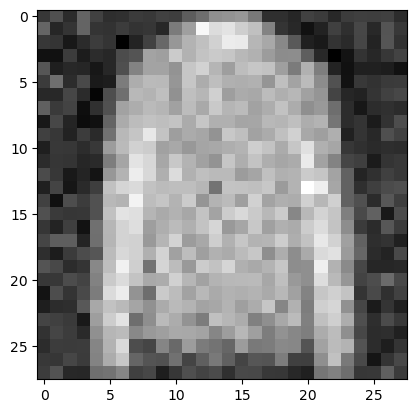

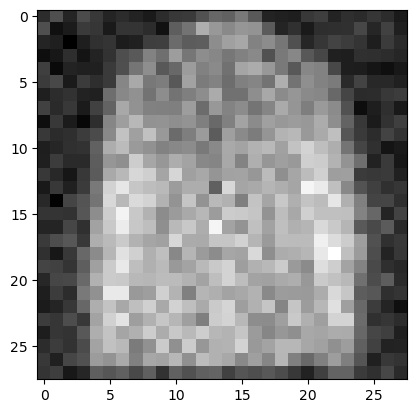

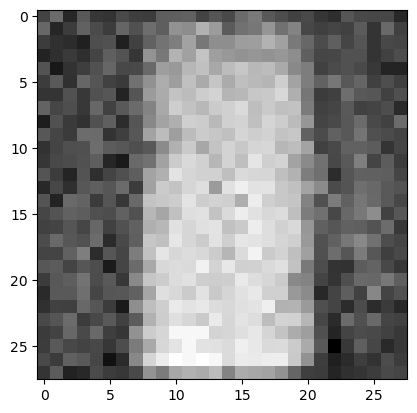

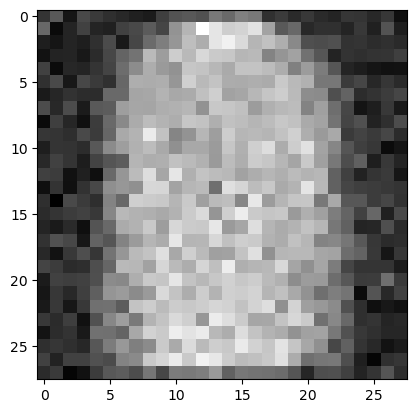

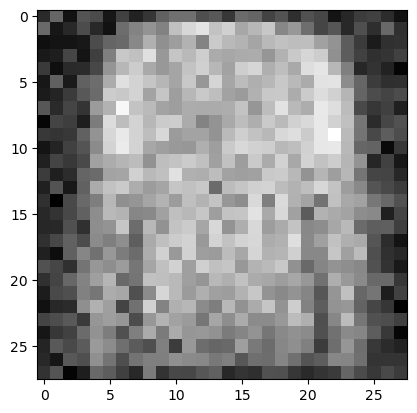

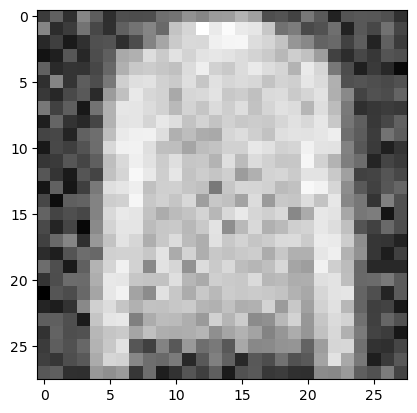

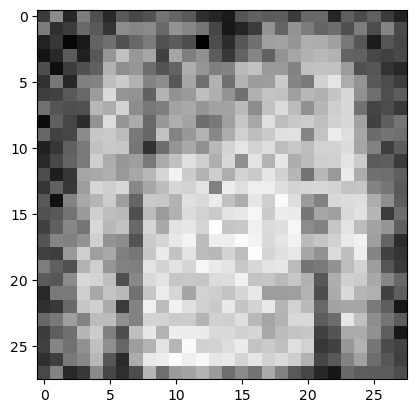

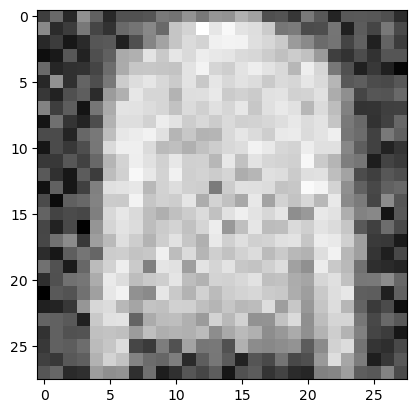

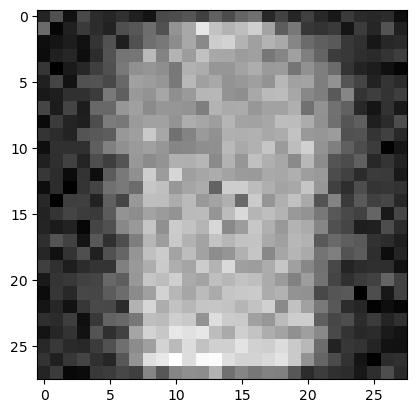

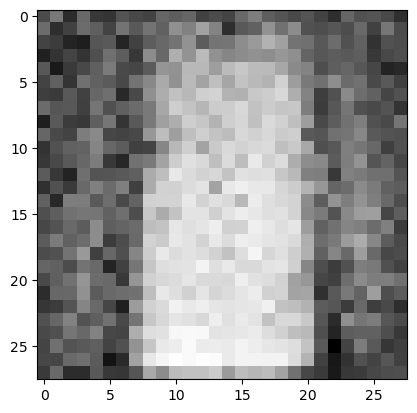

In [33]:
for i in range(10):
    plt.imshow(ck_img1.data.cpu().numpy()[i].reshape(28,28),cmap='gray')
    plt.show()

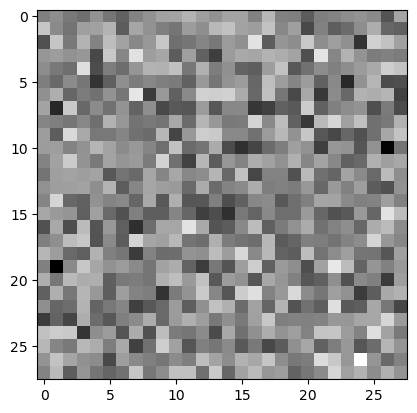

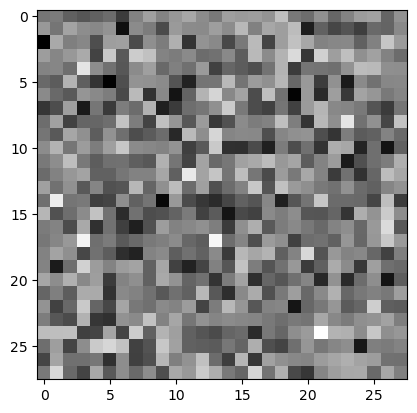

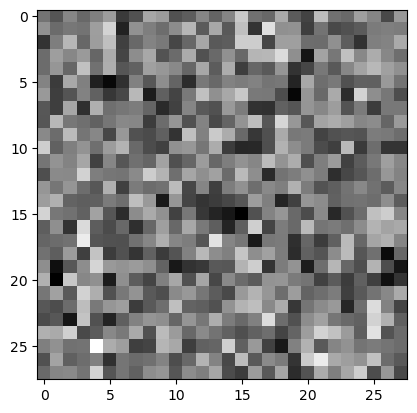

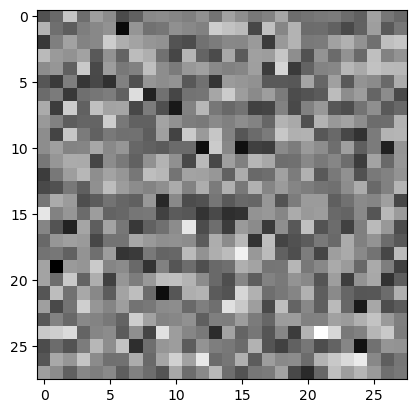

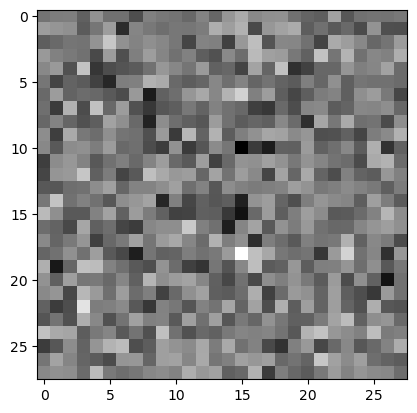

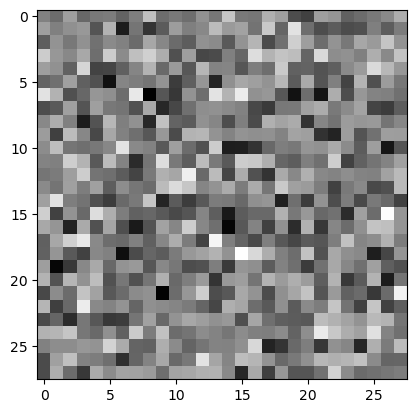

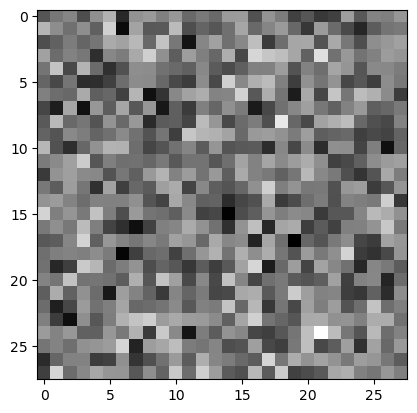

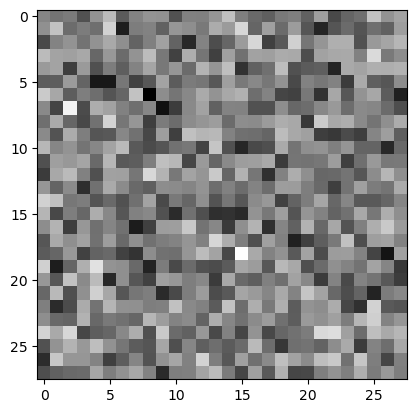

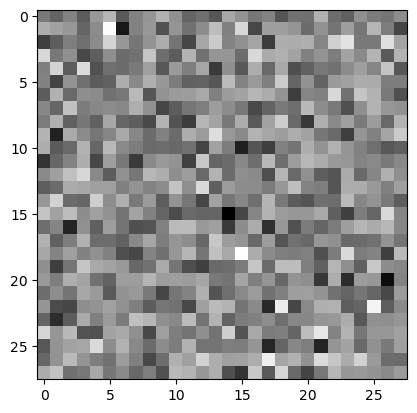

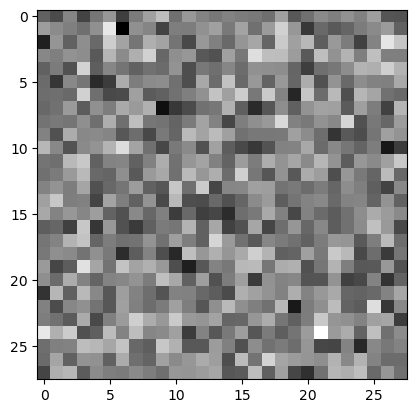

In [34]:
for i in range(10):
    plt.imshow(ck_img2.data.cpu().numpy()[i].reshape(28,28),cmap='gray')
    plt.show()

# MNIST 데이터를 이용하여 GAN모델을 만들어 학습후 결과를 출력하시오

In [36]:
#1. 데이터 로드 (데이터 분할시 남는 갯수 없이 만들기 <배치 크기 선정>)
#2. 판별자와 생성자의 모양은 자유롭게 단 너무 깊게는 권장 안함
#3. 학습의 에폭은 30으로 한정

In [39]:
EPOCHS=10
BATCH_SIZE=100
tr_ds=datasets.MNIST(root='./data/',train=True,download=True,transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))]))
tr_ds_loader=torch.utils.data.DataLoader(tr_ds,batch_size=BATCH_SIZE,shuffle=True,drop_last=True)

In [41]:
G=nn.Sequential(
    nn.Linear(64,256),
    nn.ReLU(),
    nn.Linear(256,256),
    nn.ReLU(),
    nn.Linear(256,784),
    nn.Tanh()
)
D=nn.Sequential(
    nn.Linear(784,256),
    nn.LeakyReLU(0.2),
    nn.Linear(256,256),
    nn.LeakyReLU(0.2),
    nn.Linear(256,1),
    nn.Sigmoid()
)
G=G.to(DEVICE)
D=D.to(DEVICE)
criterion=nn.BCELoss()
d_opt=optim.Adam(D.parameters(),lr=0.0002)
G_opt=optim.Adam(G.parameters(),lr=0.0002)
for epoch in range(EPOCHS):
    for i,(x,_) in enumerate(tr_ds_loader):
        data=x.reshape(BATCH_SIZE,-1).to(DEVICE)
        r_label=torch.ones(BATCH_SIZE,1).to(DEVICE)
        f_label=torch.zeros(BATCH_SIZE,1).to(DEVICE)
        #1. 진짜 데이터 판별
        output=D(data)
        d_loss_real=criterion(output,r_label)
        real_sc=output

        z=torch.randn(BATCH_SIZE,64).to(DEVICE)
        f_data=G(z)

        #2. 가짜 데이터 판별
        output=D(f_data)
        d_loss_fake=criterion(output,f_label)
        fake_sc=output
        #판별오차 토출
        d_loss=d_loss_real+d_loss_fake

        #초기화
        G_opt.zero_grad()
        d_opt.zero_grad()
        #판별자 학습
        d_loss.backward()
        d_opt.step()

        #생성오차 도출
        f_data=G(z)
        output=D(f_data)
        g_loss=criterion(output,r_label)
        

        #생성자 학습
        G_opt.zero_grad()
        d_opt.zero_grad()
        g_loss.backward()
        G_opt.step()
        
    print(f"{epoch}회 d_loss{d_loss.item()},g_loss{g_loss.item()}, D(G(z)):{fake_sc.mean()},D(x):{real_sc.mean()}")

0회 d_loss0.10115808993577957,g_loss3.8743033409118652, D(G(z)):0.09489749372005463,D(x):0.9993156790733337
1회 d_loss0.5090106129646301,g_loss2.378237724304199, D(G(z)):0.3048304319381714,D(x):0.9157764911651611
2회 d_loss0.5868662595748901,g_loss1.6024243831634521, D(G(z)):0.13087671995162964,D(x):0.80657958984375
3회 d_loss0.12231603264808655,g_loss4.8541107177734375, D(G(z)):0.033038150519132614,D(x):0.9481794238090515
4회 d_loss0.08396121114492416,g_loss4.55655574798584, D(G(z)):0.05132964253425598,D(x):0.9768810868263245
5회 d_loss0.17973144352436066,g_loss3.4704689979553223, D(G(z)):0.07327111810445786,D(x):0.9331547617912292
6회 d_loss0.19886130094528198,g_loss4.918347358703613, D(G(z)):0.013371508568525314,D(x):0.9212773442268372
7회 d_loss0.34333229064941406,g_loss4.578083515167236, D(G(z)):0.03576521575450897,D(x):0.8793253302574158
8회 d_loss0.29054880142211914,g_loss5.069607734680176, D(G(z)):0.03380864858627319,D(x):0.9061461091041565
9회 d_loss0.4436705410480499,g_loss4.1817612648

In [42]:
G1=nn.Sequential(
    nn.Linear(64,256),
    nn.ReLU(),
    nn.Linear(256,256),
    nn.ReLU(),
    nn.Linear(256,784),
    nn.Tanh()
)
G1=G1.to(DEVICE)

In [43]:
z=torch.randn(BATCH_SIZE,64).to(DEVICE)
ck_img1=G(z)
ck_img2=G1(z)

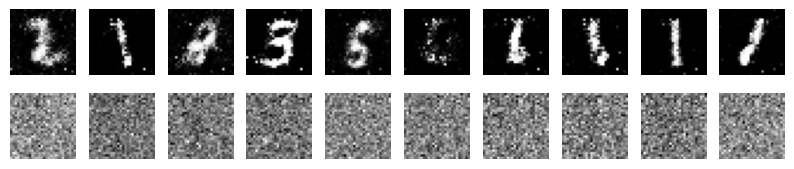

In [44]:
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(ck_img1.data.cpu().numpy()[i].reshape(28,28),cmap='gray')
    plt.axis('off')
    plt.subplot(2,10,10+i+1)
    plt.imshow(ck_img2.data.cpu().numpy()[i].reshape(28,28),cmap='gray')
    plt.axis('off')
plt.show()

In [45]:
D=nn.Sequential(
    nn.Conv2d(1,12,kernel_size=3,padding='same'),#[1,28,28]이미지 입력
    nn.MaxPool2d(2),#[12,28,28]
    nn.Conv2d(12,24,kernel_size=3,padding='same'),#[12,14,14]
    nn.MaxPool2d(2),#[24,7,7]
    nn.Flatten(),#[1176]
    nn.Linear(1176,1),#정답도출
    nn.Sigmoid()#판별 활성화
)
for i in tr_ds_loader:
    print(D(i[0]).shape)
    break

torch.Size([64, 1])


In [46]:
G=nn.Sequential(
    nn.Linear(100, 24*7*7),#z 이미지 입력을 위한 크기 조정
    nn.Unflatten(1, (24, 7, 7)),#백터 이미지 차원구조화[24,7,7]
    nn.ConvTranspose2d(24,12,4,2,1),#[12,14,14]
    nn.ConvTranspose2d(12,1,4,2,1),#[1,28,28]
)
z=torch.randn(1,100)
print(G(z).shape)

torch.Size([1, 1, 28, 28])
